#11/8

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score

In [42]:
car_df=pd.read_csv("cars.csv")
car_df

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


In [43]:
#Basic Eda

car_df.shape

(81, 5)

In [44]:
car_df.columns

Index(['HP', 'MPG', 'VOL', 'SP', 'WT'], dtype='str')

In [45]:
car_df.info

<bound method DataFrame.info of      HP        MPG  VOL          SP         WT
0    49  53.700681   89  104.185353  28.762059
1    55  50.013401   92  105.461264  30.466833
2    55  50.013401   92  105.461264  30.193597
3    70  45.696322   92  113.461264  30.632114
4    53  50.504232   92  104.461264  29.889149
..  ...        ...  ...         ...        ...
76  322  36.900000   50  169.598513  16.132947
77  238  19.197888  115  150.576579  37.923113
78  263  34.000000   50  151.598513  15.769625
79  295  19.833733  119  167.944460  39.423099
80  236  12.101263  107  139.840817  34.948615

[81 rows x 5 columns]>

In [46]:
car_df.isna().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

In [47]:
car_df.dtypes

HP       int64
MPG    float64
VOL      int64
SP     float64
WT     float64
dtype: object

In [48]:
car_df.describe()

,HP,MPG,VOL,SP,WT
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432,121.540272,32.412577
std,57.113502,9.131445,22.301497,14.181432,7.492813
min,49.000000,12.101263,50.000000,99.564907,15.712859
25%,84.000000,27.856252,89.000000,113.829145,29.591768
50%,100.000000,35.152727,101.000000,118.208698,32.734518
75%,140.000000,39.531633,113.000000,126.404312,37.392524
max,322.000000,53.700681,160.000000,169.598513,52.997752


# Check the distribution

<function matplotlib.pyplot.show(close=None, block=None)>

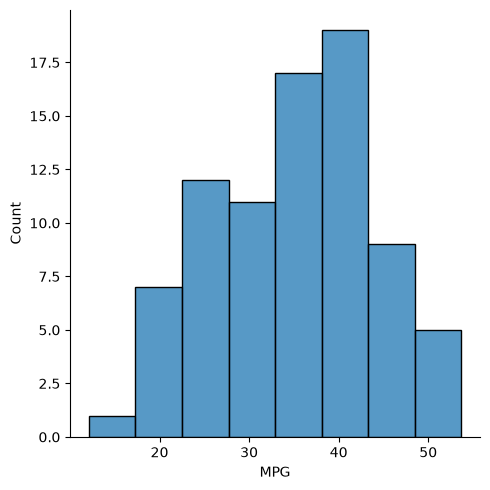

In [9]:
sns.displot(data=car_df["MPG"])
plt.show

# Assumptions

1.Linearity
2.Multicolinearity
3.Auto regression
4.Homoscadacity
5.Zero residual mean

# Linearity -----> There should be a strong relationship between independent and dependent variables

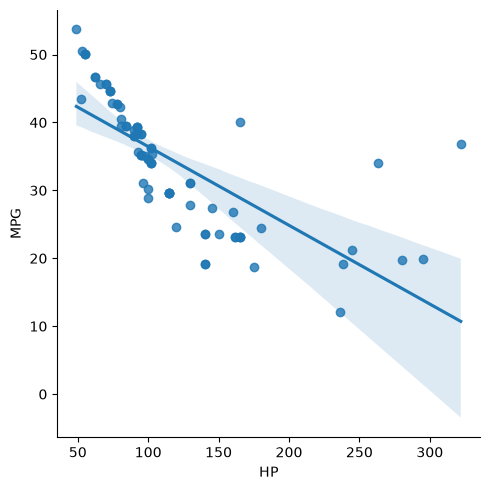

In [10]:
sns.lmplot(data=car_df,x="HP",y="MPG")

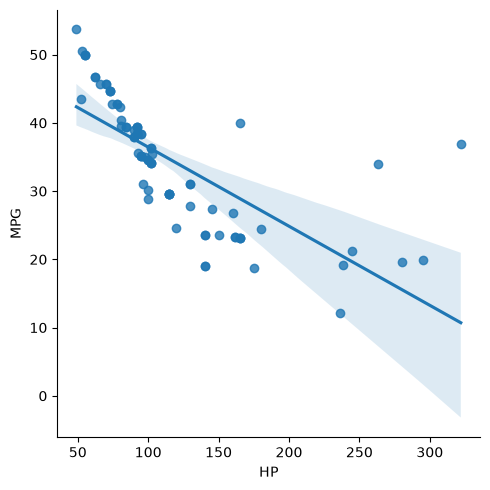

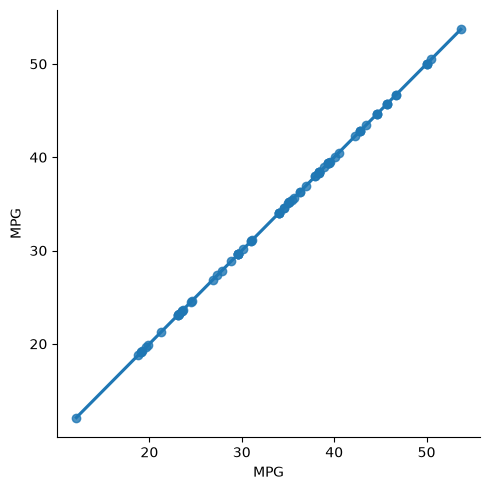

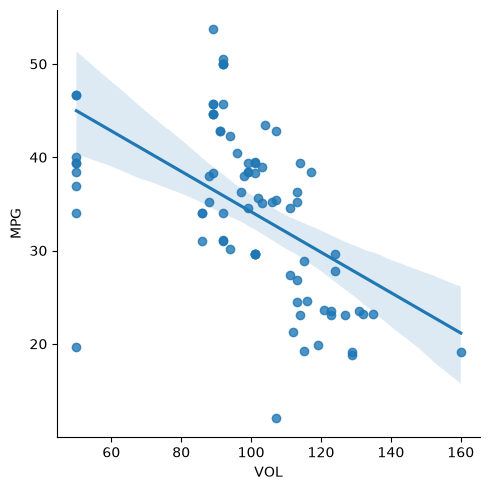

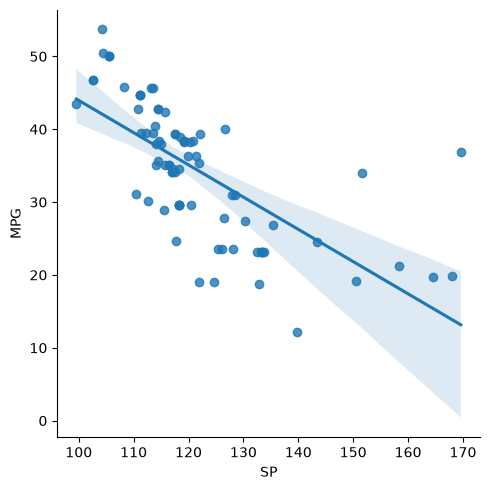

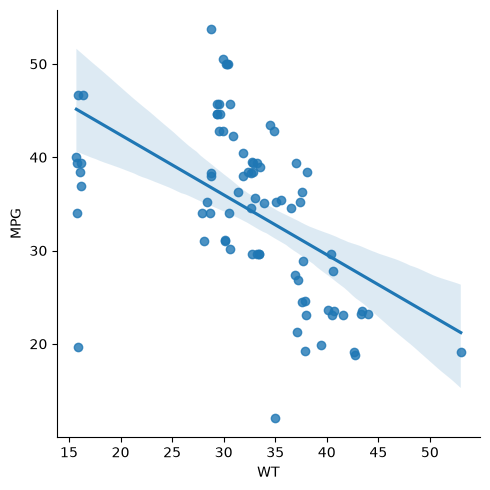

In [11]:
for i in car_df.columns:
    sns.lmplot(data=car_df,x=i,y="MPG")

# Linearity failed

# Multicolinearity -----> There should not be a relationship between independent feature

In [12]:
car_df.corr()

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


<Axes: >

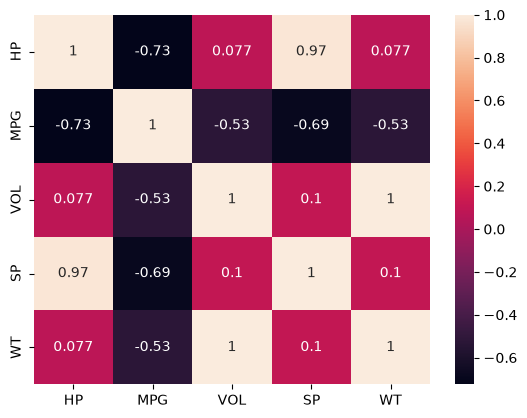

In [13]:
sns.heatmap(car_df.corr(),annot=True)

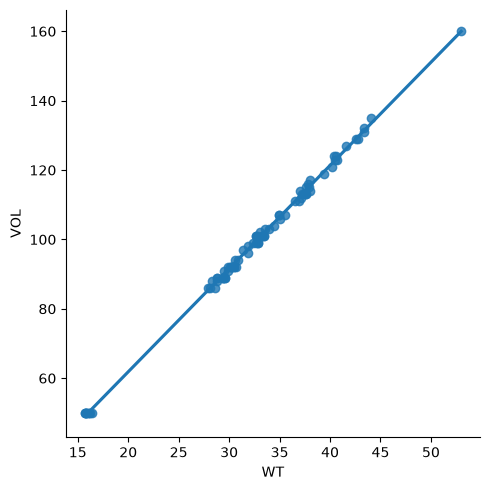

In [14]:
sns.lmplot(data=car_df,x="WT",y="VOL")

# Multicolinearity failed

# Auto regression -----> There should not be a time dependent data

# Auto regression passed

In [15]:
x=car_df.drop(labels="MPG",axis=1)
y=car_df[["MPG"]]

# Model training and model testing

In [16]:
Model_1=LinearRegression()
Model_1.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 4)","[[-0.21,-0.34, 0.4 , 0.4 ]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['HP','VOL','SP','WT']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[30.68]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [17]:
Model_1.coef_

array([[-0.20544372, -0.33605084,  0.39562692,  0.40057409]])

In [18]:
Model_1.intercept_

array([30.67733585])

In [19]:
y_pred_=Model_1.predict(x)
y_pred_

array([[43.44193477],
       [42.38879289],
       [42.27934147],
       [42.53835981],
       [42.17264802],
       [43.02061916],
       [42.32536062],
       [48.07621852],
       [48.28120247],
       [40.79122814],
       [41.52153227],
       [47.80956747],
       [39.95980269],
       [41.52757889],
       [41.76632332],
       [41.6181448 ],
       [41.15094046],
       [47.98605515],
       [41.30861046],
       [37.87127922],
       [38.57706414],
       [37.35199705],
       [37.89770285],
       [39.5625144 ],
       [39.93380662],
       [46.73870908],
       [35.48165898],
       [38.78152504],
       [38.24861192],
       [36.00285298],
       [34.84603989],
       [37.21630246],
       [37.13919796],
       [34.82541399],
       [37.22361389],
       [37.53950097],
       [39.27144845],
       [38.24219888],
       [38.54286458],
       [35.9391722 ],
       [34.2129755 ],
       [35.36313259],
       [37.50473376],
       [38.07998482],
       [35.79651664],
       [36

In [20]:
y

,MPG
0,53.700681
1,50.013401
2,50.013401
3,45.696322
4,50.504232
...,...
76,36.900000
77,19.197888
78,34.000000
79,19.833733


# Evalution metrics for regression problems

1.Mean absolute error  #must become 0
2.Mean squared error
3.Root mean squared error
4.R2 score        #must become 1

In [21]:
mean_absolute_error(y,y_pred_)

3.267968285420799

In [22]:
r2_score(y,y_pred_)

0.7705372737359844

# Zero residual mean ------> the error mean value or residual mean value should be zero

In [23]:
error=y-y_pred_
error

,MPG
0,10.258747
1,7.624608
2,7.734060
3,3.157963
4,8.331584
...,...
76,15.617904
77,1.298838
78,7.863547
79,7.517122


In [24]:
np.mean(error)

np.float64(3.50885301609926e-16)

# Zero residual mean passed

# Homoscadacity ----> constant variance and errors

# Homoscadacity failed

# Data transformation Techniques

## Regression

1.Log Transformation
2.Square root transformation
3.Cube root transformation
4.Reciprocal transformation
5.Standard scaler
6.Min max scaler


## Clasification

1.One hot encoding
2.Label encoding

In [39]:
car_df["Log_hp"]=np.log(car_df["HP"])
car_df["Log_sp"]=np.log(car_df["SP"])
car_df["Log_VOL"]=np.log(car_df["VOL"])
car_df["Log_Wt"]=np.log(car_df["WT"])

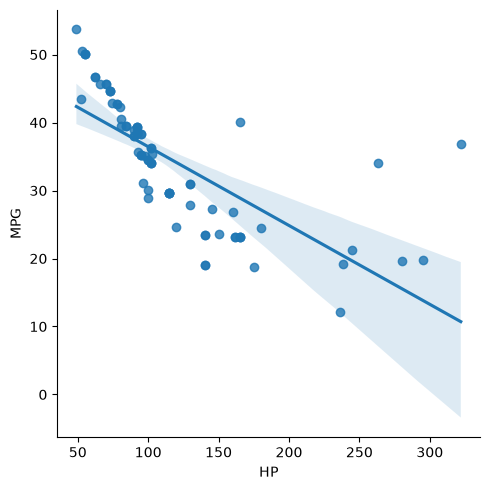

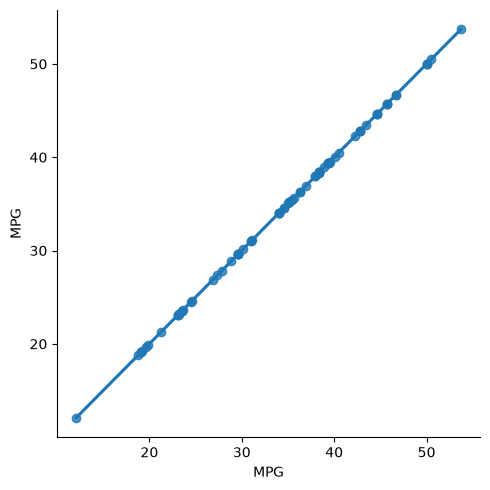

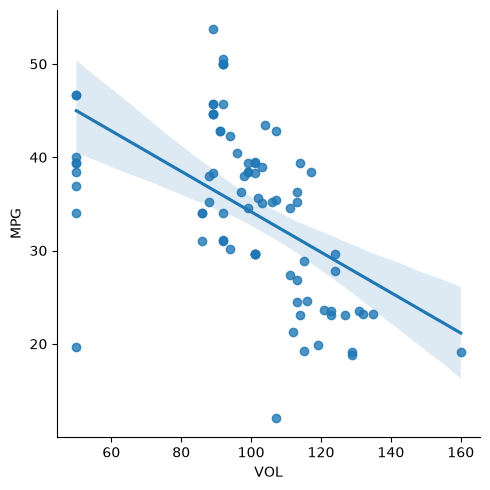

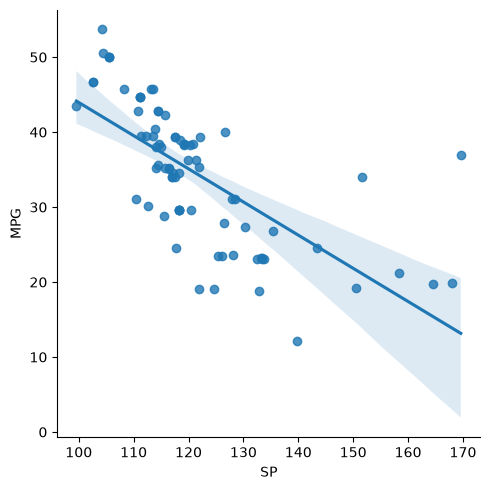

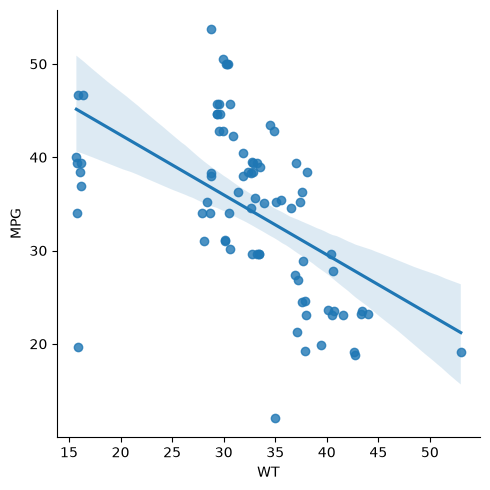

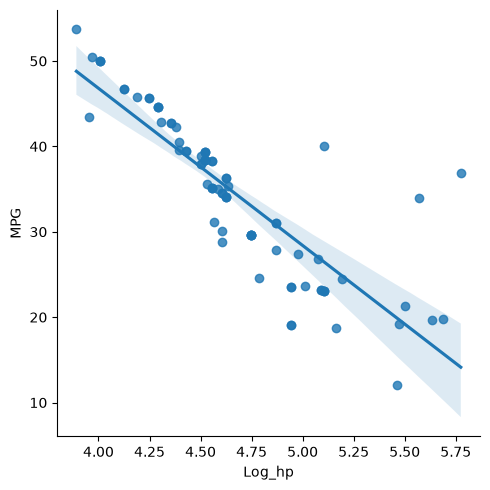

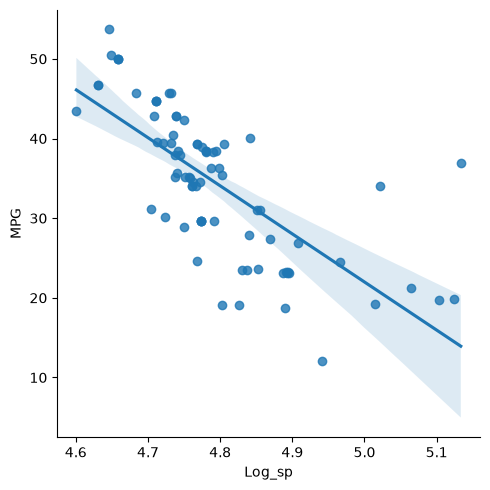

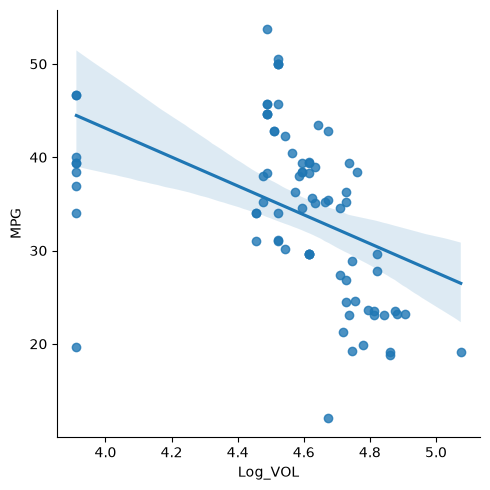

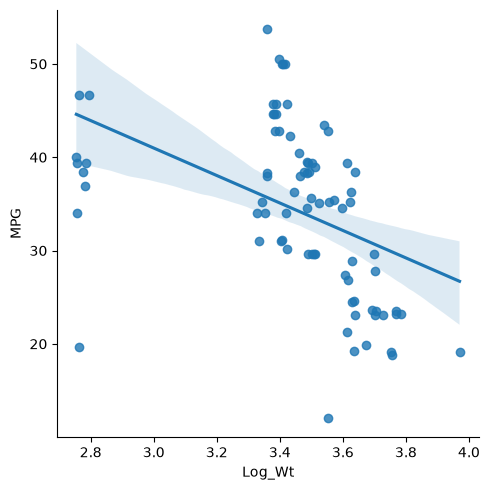

In [40]:
for i in car_df.columns:
    sns.lmplot(data=car_df,x=i,y="MPG")

#12/8

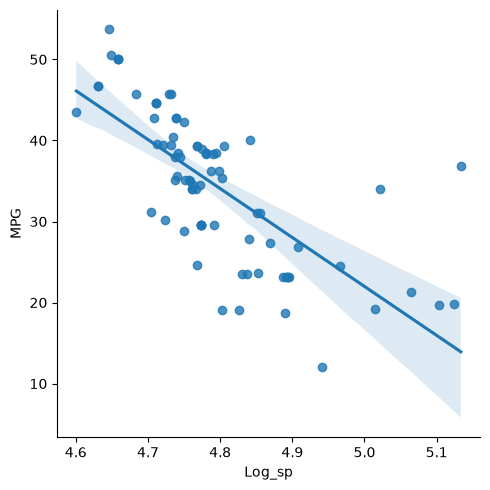

In [44]:
sns.lmplot(data=car_df,x="Log_sp",y="MPG")

In [31]:
X=car_df[["Log_hp","SP","VOL"]]
y=car_df["MPG"]

In [32]:
Model_2=LinearRegression()
Model_2.fit(X,y)
y_pred_train=Model_2.predict(X)            

In [33]:
r2_score(y,y_pred_train)

0.9127312685751964

In [34]:
mean_absolute_error(y,y_pred_train)

1.6540965325800137

# To Improve R2 Score Remove Outliers

In [45]:
columns=["Log_hp","SP","VOL","MPG"]

for cols in columns:
    q1=car_df[cols].quantile(0.25)
    q3=car_df[cols].quantile(0.75)

    IQR=q3-q1

    lower=q1-1.5*IQR    #1.5 threshold value
    upper=q3+1.5*IQR

    car_df=car_df[(car_df[cols]>=lower)&(car_df[cols]<=upper)]

In [49]:
car_df.reset_index(inplace=True)   #must reset after removing outliers

In [50]:
del car_df["index"]

In [51]:
X=car_df[["Log_hp","SP","VOL"]]
y=car_df["MPG"]

In [52]:
final_model=LinearRegression()
final_model.fit(X,y)
y_pred_train=final_model.predict(X)   

In [53]:
r2_score(y,y_pred_train)

0.9831486200683976

In [54]:
mean_absolute_error(y,y_pred_train)

0.7797263121248754

In [55]:
import joblib   #this file should be dumped in pickle file so that this file directly loads for frontend creation.(flask)

joblib.dump(final_model,"F_model.pkl")

['F_model.pkl']

 # 12-16 homeworks (Linear Regression)

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score

In [2]:
Adv_df=pd.read_csv("Advertising.csv")
Adv_df

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [3]:
#Basic Eda

Adv_df.shape

(200, 5)

In [4]:
Adv_df.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')

In [5]:
Adv_df.info

<bound method DataFrame.info of      Unnamed: 0     TV  Radio  Newspaper  Sales
0             1  230.1   37.8       69.2   22.1
1             2   44.5   39.3       45.1   10.4
2             3   17.2   45.9       69.3    9.3
3             4  151.5   41.3       58.5   18.5
4             5  180.8   10.8       58.4   12.9
..          ...    ...    ...        ...    ...
195         196   38.2    3.7       13.8    7.6
196         197   94.2    4.9        8.1    9.7
197         198  177.0    9.3        6.4   12.8
198         199  283.6   42.0       66.2   25.5
199         200  232.1    8.6        8.7   13.4

[200 rows x 5 columns]>

In [6]:
Adv_df.isna().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [7]:
Adv_df.dtypes

Unnamed: 0      int64
TV            float64
Radio         float64
Newspaper     float64
Sales         float64
dtype: object

In [8]:
Adv_df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [9]:
Adv_df.drop("Unnamed: 0",axis=1,inplace=True)

# Check the distribution

<function matplotlib.pyplot.show(close=None, block=None)>

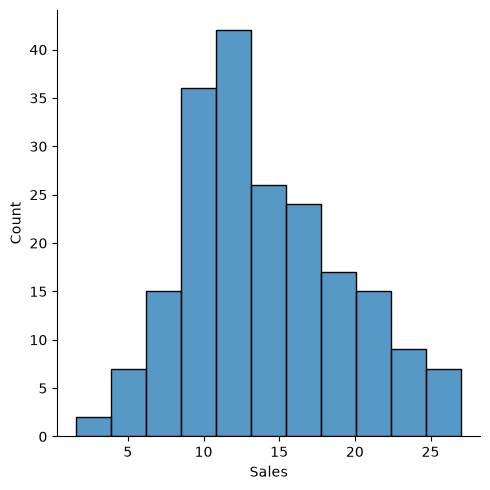

In [10]:
sns.displot(data=Adv_df["Sales"])
plt.show

# Assumptions

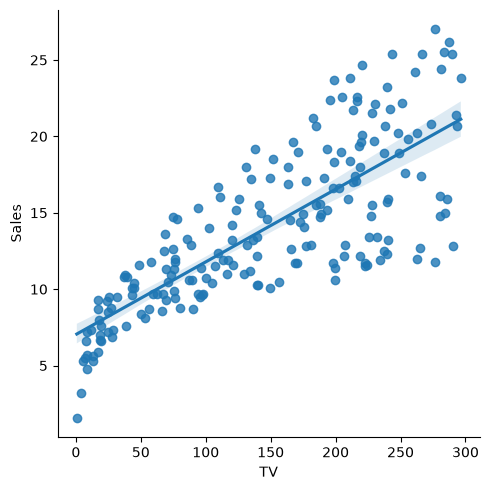

In [11]:
#1.Linearity

sns.lmplot(data=Adv_df,x="TV",y="Sales")

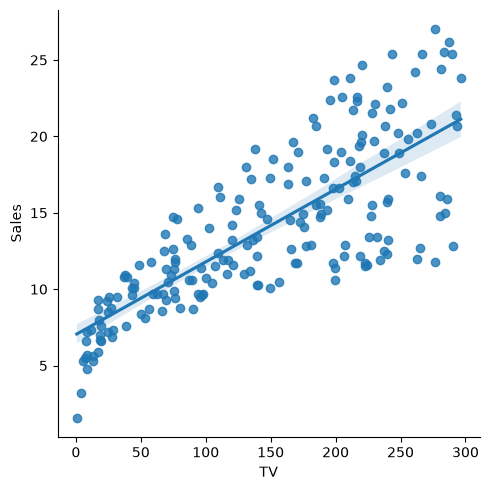

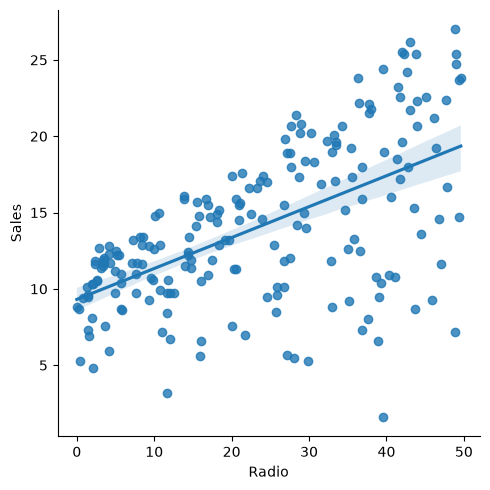

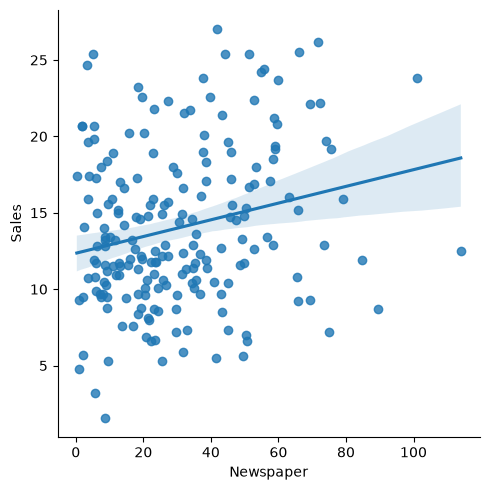

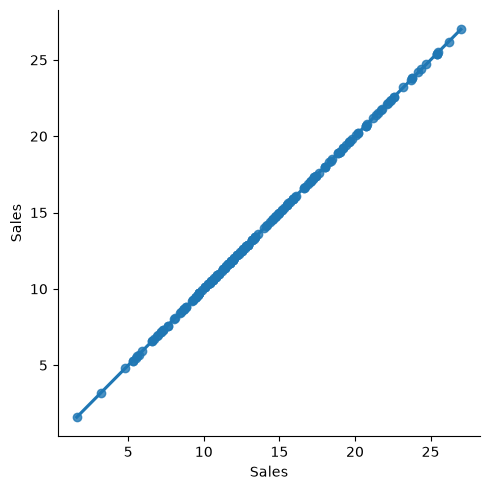

In [12]:
for i in Adv_df.columns:
    sns.lmplot(data=Adv_df,x=i,y="Sales")

# Linearity passed

In [13]:
#2.Multicolinearity

Adv_df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


<Axes: >

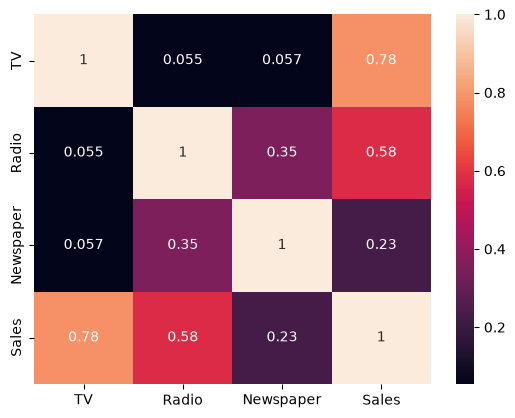

In [14]:
sns.heatmap(Adv_df.corr(),annot=True)

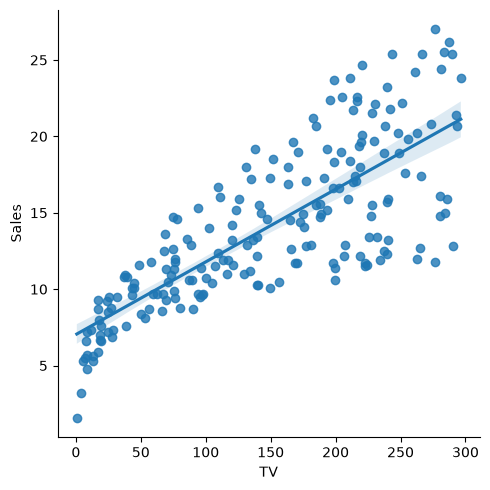

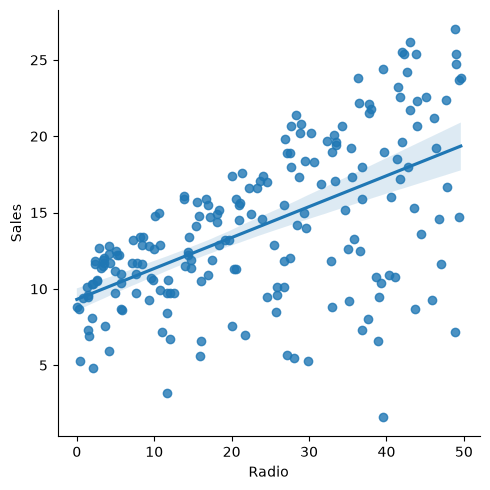

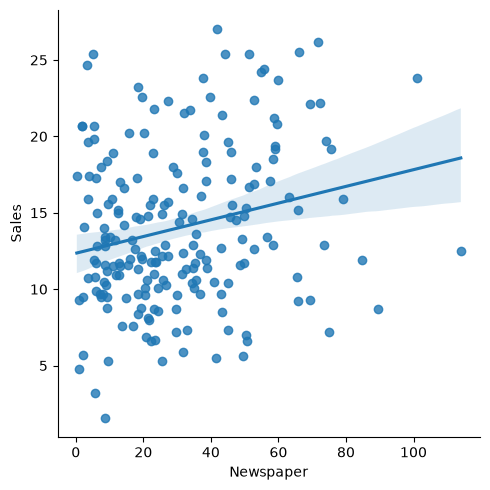

In [15]:
sns.lmplot(data=Adv_df,x="TV",y="Sales")
sns.lmplot(data=Adv_df,x="Radio",y="Sales")
sns.lmplot(data=Adv_df,x="Newspaper",y="Sales")

# Multicolinearity passed

In [16]:
#3.Auto Regression (its not a time dependent data)

# Auto regression passed

In [17]:
x=Adv_df[["TV","Radio","Newspaper"]]
y=Adv_df["Sales"]

# Model training and Model testing

In [18]:
Model_1=LinearRegression()
Model_1.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0.05, 0.19,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['TV','Radio','Newspaper']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.939
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [19]:
Model_1.coef_

array([ 0.04576465,  0.18853002, -0.00103749])

In [20]:
Model_1.intercept_

np.float64(2.938889369459412)

In [21]:
y_pred_=Model_1.predict(x)
y_pred_

array([20.52397441, 12.33785482, 12.30767078, 17.59782951, 13.18867186,
       12.47834763, 11.72975995, 12.12295317,  3.72734086, 12.55084872,
        7.0322992 , 17.28512918, 10.57712073,  8.82630048, 18.43436638,
       20.81929952, 12.82365674, 23.22495716,  9.95168206, 14.16607293,
       18.10076728, 14.7405382 ,  6.4891503 , 16.5459329 ,  8.14651887,
       15.6100386 , 14.98951429, 17.05167344, 19.41053803,  9.14402389,
       21.6339338 , 11.3460929 ,  7.63888314, 18.86426829,  7.57483051,
       17.00682618, 23.40590052, 15.62347779,  9.90868103, 20.44761039,
       16.37766467, 17.2959832 , 21.59580326, 13.96385684,  8.88787996,
       15.16152314,  8.87338673, 21.7226299 , 16.26362018,  8.1681656 ,
       12.63121132,  9.33981296, 20.66297563, 19.94469957, 20.37443008,
       21.2926106 ,  8.52771254, 12.77458802, 21.89805198, 18.13348698,
        5.74215558, 22.89067208, 16.78426073, 13.21069202, 16.97773556,
        7.84904532,  9.01603163, 12.0370073 , 18.97657924, 21.10

In [22]:
y

0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: Sales, Length: 200, dtype: float64

In [23]:
mean_absolute_error(y,y_pred_)

1.2520112296870685

In [24]:
r2_score(y,y_pred_)

0.8972106381789522

In [25]:
#4.Homoscadacity  (it has constant variance and errors)

# Homoscadacity passed

In [26]:
#5.Zero Residual mean

error=y-y_pred_
error

0      1.576026
1     -1.937855
2     -3.007671
3      0.902170
4     -0.288672
         ...   
195    2.229658
196    1.534688
197    0.014079
198    1.732679
199   -1.773196
Name: Sales, Length: 200, dtype: float64

In [27]:
np.mean(error)

np.float64(-6.039613253960852e-16)

# Zero residual mean passed

In [59]:
columns=["TV","Radio","Newspaper","Sales"]

for cols in columns:
    q1=Adv_df[cols].quantile(0.25)
    q3=Adv_df[cols].quantile(0.75)

    IQR=q3-q1

    lower=q1-1.5*IQR    
    upper=q3+1.5*IQR

    Adv_df=Adv_df[(Adv_df[cols]>=lower)&(Adv_df[cols]<=upper)]

In [60]:
Adv_df.reset_index(inplace=True)

In [61]:
del Adv_df["index"]

In [65]:
x=Adv_df[["TV","Radio","Newspaper"]]
y=Adv_df["Sales"]

In [68]:
final_model=LinearRegression()

In [69]:
final_model.fit(x,y)

ValueError: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by LinearRegression.

In [28]:
#Dump/save LR model

In [110]:
import joblib

In [111]:
joblib.dump(Model_1,"Advertising_linear_model.pkl")

['Advertising_linear_model.pkl']